# List 5
## Author: Jan Pułtorak

In [2]:
import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed);

## Task 1

In [2]:
B = 4
d = 3
x = torch.rand(B, d)
bn_layer = nn.BatchNorm1d(d)

bn_layer.train()
def custom_bn(x: torch.Tensor, eps = 1e-05, gamma = 1, beta = 0, mean=None, var=None) -> torch.Tensor:
    if mean is None:
        mean = x.mean(dim=0)
    if var is None:
        var = x.var(dim=0, correction=0)
    return (x - mean)/(torch.sqrt(var+eps)) * gamma + beta

x_out = bn_layer(x)
x_out_custom = custom_bn(x)
x_out, x_out_custom

(tensor([[ 0.8850,  0.7142, -1.2338],
         [ 1.0951, -1.6785, -0.1432],
         [-0.8218,  0.1606,  1.5569],
         [-1.1584,  0.8036, -0.1798]], grad_fn=<NativeBatchNormBackward0>),
 tensor([[ 0.8850,  0.7142, -1.2338],
         [ 1.0951, -1.6785, -0.1432],
         [-0.8218,  0.1606,  1.5569],
         [-1.1584,  0.8036, -0.1798]]))

In [3]:
bn_layer.eval()
print(bn_layer.running_mean, bn_layer.running_var)
bn_layer(x), custom_bn(x, mean=bn_layer.running_mean, var=bn_layer.running_var)

tensor([0.0558, 0.0758, 0.0630]) tensor([0.9179, 0.9064, 0.9053])


(tensor([[0.8626, 0.8814, 0.3362],
         [0.9430, 0.3304, 0.5654],
         [0.2096, 0.7539, 0.9226],
         [0.0808, 0.9020, 0.5577]], grad_fn=<NativeBatchNormBackward0>),
 tensor([[0.8626, 0.8814, 0.3362],
         [0.9430, 0.3304, 0.5654],
         [0.2096, 0.7539, 0.9226],
         [0.0808, 0.9020, 0.5577]]))

### Explanations
1. **What changes between training mode and evaluation mode**

    In training mode, mean and variance used in normalization are calculated from the batch, while in evaluation mode the layer keeps track of a running mean and variance (across multiple batches).

2. **What `running_mean` and `running_var` represent**
    They are estimates of mean and variance across already batches which were passed through the layer so far.

3. **Why the outputs in train and eval mode are generally different**
    In training mode, mean and variance used in normalization are calculated from the batch, while in evaluation mode the layer keeps track of a running mean and variance (across multiple batches). Even for one batch, results will be different, as running statistics are calculated using exponential moving average.

4. **Why this matters during inference**
    In inference, we often pass just one instance of a problem, so normalization based on the "batch" (of size 1) does not make sense, and using running mean and var will be much more accurate.


## Task 2

In [4]:
simple_cnn = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 10)
)

### Shapes calculation
Batch size is irrelevant, each layer will have an extra batch dimension that remains unchanged throughout the entire network. The input is an RGB image: $3 \times 32 \times 32$
1. The first `Conv2d` layer has 3 input channels, and 16 output channels, so $16$ total filters. Width and height will be: $32-3 + 2*\text{padding} + 1 = 32$. So the output size will be $16 \times 32 \times 32$.
2. `RELU` does not affect shape, so still $16 \times 32 \times 32$.
3. `MaxPool2d` does not affect number of channels. Both width and height will be $(32-2)/2 + 1 = 16$, so the output shape is $16 \times 16 \times 16$
4. `Conv2d` with 16 input and 32 output channels. Since $\text{kernel\_size} = 2*\text{padding} +1$ and stride is $1$, w and h remain unchanged, so output shape is $32 \times 16 \times 16$.
5. `Batchnorm2d` performs normalization only, shape is not affected.
6. `RELU` does not affect shapes.
7. `MaxPool2d` with kernel size = 2, stride = 2, padding = 0 will result in $32x8x8$ output.
8. `Flatten` results in 1D output $32 \times 8 \times 8 = 2048$.
9. `nn.Linear(32 * 8 * 8, 10)` is 10 dot products with biases, so the result is a $1D$ tensor of size $10$.

### Trainable Parameters
* **First Convolution Layer:** has $16$ filters, each of size $3 \times 3 \times 3$. $(3 \times 16 \times 3 \times 3) \text{ weights} + 16 \text{ biases} = 448$
* **Second Convolution Layer:** $(16 \times 32 \times 3 \times 3) \text{ weights} + 32 \text{ biases} = 4640$
* **BatchNorm Layer:** $32 \text{ scales} + 32 \text{ shifts} = 64$
* **Final Linear Layer:** $(2048 \times 10) \text{ weights} + 10 \text{ biases} = 20490$
* `RELU`, `MaxPool2d`, `Flatten` do not have trainable parameters.

### Spatial Resolution
* The spatial resolution changes exactly at the two `MaxPool2d` layers.
* **Why MaxPool2d(2) reduces height and width:** A kernel size of 2 with a default stride of 2 means a $2 \times 2$ window slides across the image taking non-overlapping steps. Extracting one maximum value for every $2 \times 2$ grid cuts the spatial dimensions exactly in half.
* **Why BatchNorm2d(32) does not change tensor shape:** It performs element wise normalization
## Explanation

1. When applying filter $W_f \times H_f$ to a $W \times H \times C$ image, the width (height analogously) results in a $$\frac{(W-W_f + 2*\text{padding})}{\text{stride}} + 1$$
That is why convolution preserves or changes spatial size depending on stride and padding.
2. The final linear layer calculates a dot product, which operates on vectors, so the input must be flattened before.

## Task 3

In [3]:
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
from torchvision import datasets, transforms

device = None
if not torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

else:
    print("MPS enabled")
    device = torch.device("mps")

transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

MPS enabled


/Users/janek/dev/uwr/neural-networks/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


In [6]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [7]:
model_a = SimpleCNN().to(device)
print(model_a)

trainable_params = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

SimpleCNN(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2048, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 268650


Epoch 01/20 | Train Loss: 2.0486, Acc: 0.2579 | Val Loss: 1.7727, Acc: 0.3660
Epoch 02/20 | Train Loss: 1.6728, Acc: 0.4043 | Val Loss: 1.5094, Acc: 0.4610
Epoch 03/20 | Train Loss: 1.4578, Acc: 0.4816 | Val Loss: 1.9643, Acc: 0.3448
Epoch 04/20 | Train Loss: 1.3231, Acc: 0.5297 | Val Loss: 1.3355, Acc: 0.5176
Epoch 05/20 | Train Loss: 1.2203, Acc: 0.5645 | Val Loss: 1.2161, Acc: 0.5646
Epoch 06/20 | Train Loss: 1.1358, Acc: 0.5968 | Val Loss: 1.1663, Acc: 0.5782
Epoch 07/20 | Train Loss: 1.0589, Acc: 0.6244 | Val Loss: 1.2227, Acc: 0.5660
Epoch 08/20 | Train Loss: 0.9868, Acc: 0.6539 | Val Loss: 1.1943, Acc: 0.5670
Epoch 09/20 | Train Loss: 0.9239, Acc: 0.6721 | Val Loss: 1.0788, Acc: 0.6108
Epoch 10/20 | Train Loss: 0.8612, Acc: 0.6944 | Val Loss: 1.0273, Acc: 0.6382
Epoch 11/20 | Train Loss: 0.8034, Acc: 0.7171 | Val Loss: 1.0652, Acc: 0.6334
Epoch 12/20 | Train Loss: 0.7456, Acc: 0.7398 | Val Loss: 1.1311, Acc: 0.6086
Epoch 13/20 | Train Loss: 0.6930, Acc: 0.7585 | Val Loss: 1.0049

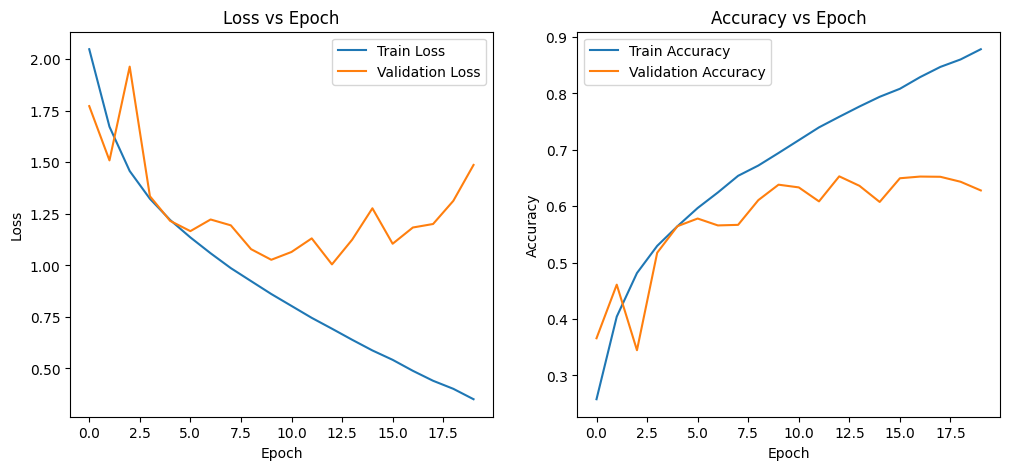

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_a.parameters(), lr=0.1)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
epochs = 20

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_a, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_a, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Explanation
1. **Thy CNNs are more suitable for images than fully-connected networks**

    Flattening an image to pass into a MLP's network destroys the 2D spatial relationships between pixels. MLP's also fully connect layer $N$ with layer $N+1$, which is inefficient and results in a huge number of weights.
2. **What local connectivity means**
    Each neuron in Convolutional Layer connects only to a small part of the image, defined by kernel size.
3. **What weight sharing means**
    Each filter slides across the entire image, with the same weights regardless of its current position. That means that each filter may learn to recognize features (corners for example) anywhere on the image.

4. **How pooling changes the representation.**
    Pooling replaces small regions with a single scalar representing some statistic over that region, like an average or maximum.